In [1]:
import anndata as ad
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
import os, sys
import mudata as md
md.set_options(pull_on_update=False)

# Include src directory in the path dynamically
notebook_dir = os.path.abspath("")
src_path = os.path.join(notebook_dir, "../src")
sys.path.append(src_path)

import preprocessing.preprocessing as preprocessing
from constants import ModalityType, MsiPreprocessingParams

## Constant Definitions

In [2]:
PATH = "/staging/leuven/stg_00077/projects/Lorenzo/FOCUS/p_LipidQMap/d_liver_VIB_Ghent"
PLOT_PATH = os.path.join(PATH, "plots", "preprocessing")
MODALITY_NAME = "MSI"
MODALITY_TYPE = ModalityType.MSI

sc.settings.figdir = PLOT_PATH

In [3]:
from sklearn.decomposition import PCA, NMF

def visualize_spatial(clusters: np.ndarray, raster_coords: np.ndarray, cluster_colors: np.ndarray, title: str):
	'''
	Visualize the raster image of one sample, coloring each raster block (data spot) according to its cluster assignment.
	
	Parameters
	----------
	clusters : np.ndarray
		Array of shape (n_spots,) containing the cluster assignment for each data spot.
	raster_coords : np.ndarray
		Array of shape (n_spots, 2, 2) containing the raster coordinates for each data spot.
	cluster_colors : np.ndarray
		Array of shape (n_clusters,) containing the hex color code for each cluster.
	title : str
		Title for the plot.
	
	'''

	# Convert the list of cluster colors into a list of RGB values
	cluster_colors_rgb = {}
	for index in range(len(cluster_colors)):
		cluster_colors_rgb[str(index)] = tuple(int(cluster_colors[index][i:i+2], 16) for i in (1, 3, 5))

	# Generate a raster image based on the raster coordinates and cluster colors
	img = np.zeros((raster_coords[:,:,1].max()+1, raster_coords[:,:,0].max()+1, 3), dtype=np.uint8)
	for index, ((x1, y1), (x2, y2)) in enumerate(raster_coords):
		img[y1:y2, x1:x2] = cluster_colors_rgb[clusters[index]]

	# Add 30 pixel padding around the image
	pad_width = 30
	img = np.pad(img, ((pad_width, pad_width), (pad_width, pad_width), (0, 0)), mode='constant', constant_values=0)

	# Display the image
	plt.figure(figsize=(15,15))
	plt.imshow(img, cmap='gray')
	plt.title(title)
	plt.show()


def visualize_spot_spatial(
        clusters: np.ndarray,
        physical_coords: np.ndarray,
        cluster_colors: np.ndarray,
		title: str,
		max_coords_value: tuple[float, float] = None
        ):
    '''
    Visualize the spatial scatter plot of sample spots, coloring each spot by cluster assignment.
    
    Parameters
    ----------
    clusters : np.ndarray
        Array of shape (n_spots,) containing cluster assignments (possibly strings).
    physical_coords : np.ndarray
        Array of shape (n_spots, 2) with (x, y) coordinates.
    cluster_colors : np.ndarray
        Array of shape (n_clusters,) of hex color strings.
    title : str
        Plot title.
    max_coords_value : tuple[float, float], optional
        If provided, sets the x and y axis limits to (0, max_value). Otherwise, axes are auto-scaled.
        If provided, the limit is increased by 5% for better visualization.
    '''
    def hex_to_rgb(hex_str):
        return tuple(int(hex_str[i:i+2], 16) / 255. for i in (1, 3, 5))

    cluster_colors_rgb = [hex_to_rgb(c) for c in cluster_colors]
    unique_clusters = sorted(np.unique(clusters))
    cluster_to_idx = {c: i for i, c in enumerate(unique_clusters)}
    cluster_indices = np.array([cluster_to_idx[c] for c in clusters])

    spot_colors = [cluster_colors_rgb[i] for i in cluster_indices]

    coords = np.asarray(physical_coords, dtype=float)
    centroid = coords.mean(axis=0)

    # Center the coordinates to plot_center
    if max_coords_value is not None:
        plot_center = np.array([max_coords_value[0] / 2., max_coords_value[1] / 2.])
    else:
        bbox_min = coords.min(axis=0)
        bbox_max = coords.max(axis=0)
        plot_center = (bbox_min + bbox_max) / 2.

    # Translate the coordinates: centroid -> plot_center
    translated = coords - centroid + plot_center

    plt.figure(figsize=(12, 12))
    plt.scatter(translated[:, 0], translated[:, 1], c=spot_colors, s=2)
    plt.title(title)
    plt.xlabel("Physical X")
    plt.ylabel("Physical Y")
    plt.gca().set_aspect('equal', adjustable='box')

    # Limits: if max_coords_value is provided, center on plot_center with a small margin
    if max_coords_value is not None:
        half = np.array([max_coords_value[0] / 2., max_coords_value[1] / 2.]) * 1.05
        plt.xlim(plot_center[0] - half[0], plot_center[0] + half[0])
        plt.ylim(plot_center[1] - half[1], plot_center[1] + half[1])
    else:
        pad = (translated.max(axis=0) - translated.min(axis=0)) * 0.05
        plt.xlim(translated[:, 0].min() - pad[0], translated[:, 0].max() + pad[0])
        plt.ylim(translated[:, 1].min() - pad[1], translated[:, 1].max() + pad[1])

    # Flip y-axis for correct orientation
    plt.gca().invert_yaxis()

    plt.show()
    plt.savefig(os.path.join(PLOT_PATH, title.replace(" ", "_") + ".png"), dpi=300)
    plt.close()

## MSI Dataset preparation and processing

In [4]:
preprocessing_settings = {
    MsiPreprocessingParams.FORCE_RECOMPUTING: False,
    MsiPreprocessingParams.FREQUENCY_THRESHOLD: 0.01,
    MsiPreprocessingParams.INTENSITY_NORMALIZATION: preprocessing.MsiIntensityNormalization.TIC,
    MsiPreprocessingParams.LIPID_ANNOTATION_DB: os.path.join(PATH, "resources", "MSI_database_POS_NEG_combined.json"),
    MsiPreprocessingParams.MASS_TOLERANCE: 10,
    MsiPreprocessingParams.BATCH_SIZE: 10000,
}

In [ ]:
processed_msi = preprocessing.preprocess_modality(
    path=PATH,
    modality_type=ModalityType.MSI,
    modality_name=MODALITY_NAME,
    preprocessing_settings=preprocessing_settings,
)

Processing Lipidomic Dataset


1/4 - Loading MSI data:   0%|          | 0/13 [00:00<?, ?sample/s]

1/4 - Loading MSI data:  38%|███▊      | 5/13 [00:29<00:48,  6.03s/sample]

## Dataset Visualization

In [6]:
# Load the merged dataset
msi_dataset = ad.read_h5ad(processed_msi['merged'])

In [ ]:
# Compute PCA and UMAP visualizations
sc.pp.pca(msi_dataset, n_comps=50, layer='X_tic')
sc.pp.neighbors(msi_dataset)
sc.tl.umap(msi_dataset)

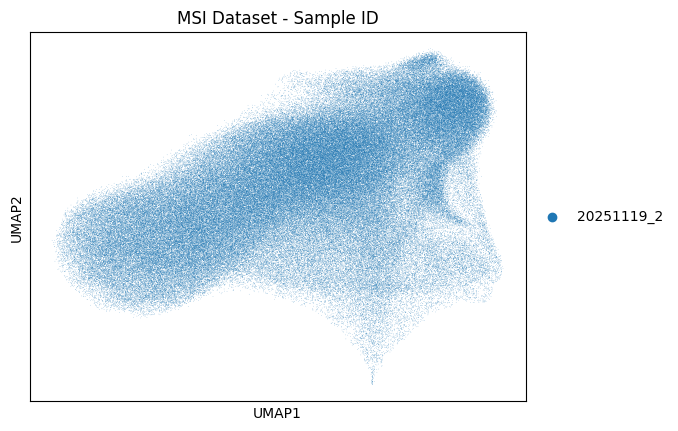

In [15]:
# Visualize the dataset
sc.pl.umap(msi_dataset, color=['sample_id'], title="MSI Dataset - Sample ID", save="_msi_dataset_sample_id.png")

In [11]:
# Perform Batch correction using Harmony
import scanpy.external as sce
msi_dataset.layers['raw'] = msi_dataset.X.copy()
msi_dataset.X = msi_dataset.layers['X_tic'].copy()

sce.pp.harmony_integrate(msi_dataset, key='sample_id')

2025-11-13 12:09:09,287 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-11-13 12:09:16,414 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-11-13 12:09:16,861 - harmonypy - INFO - Iteration 1 of 10
2025-11-13 12:10:07,574 - harmonypy - INFO - Iteration 2 of 10
2025-11-13 12:10:58,195 - harmonypy - INFO - Iteration 3 of 10
2025-11-13 12:11:48,986 - harmonypy - INFO - Converged after 3 iterations


In [7]:
msi_dataset.var['mz_mode'].value_counts()

mz_mode
neg    3782
pos    3535
Name: count, dtype: int64

In [8]:
msi_dataset.var['lipid_annotation']

0             Unannotated
1             Unannotated
2             Unannotated
3             Unannotated
4             Unannotated
              ...        
7312          Unannotated
7313          Unannotated
7314          Unannotated
7315          Unannotated
7316    GM2 42:1;O2 [M-H]
Name: lipid_annotation, Length: 7317, dtype: category
Categories (343, object): ['CAR 10:2 [M+H]+', 'CAR 18:1 [M+H]+', 'CAR 18:2 [M+H]+', 'CAR 18:2;O [M+H]+', ..., 'SM 36:2;O2 [M+K]+', 'SM 36:3;O2 [M+K]+', 'SM 39:1;O2 [M+K]+', 'Unannotated']

In [12]:
# Compute PCA and UMAP visualizations
sc.pp.neighbors(msi_dataset, use_rep='X_pca_harmony')
sc.tl.umap(msi_dataset)

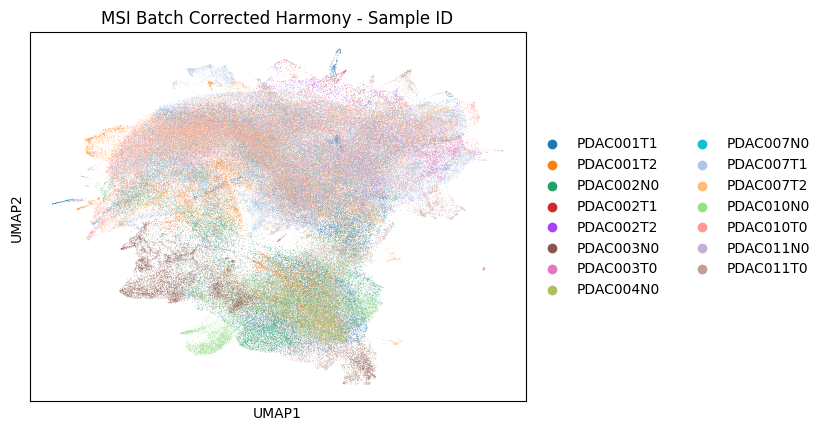

In [13]:
sc.pl.umap(msi_dataset, color=['sample_id'], title="MSI Batch Corrected Harmony - Sample ID", save="_msi_batch_corrected_harmony_sample_id.png")

In [ ]:
# Leiden clustering on the Harmony-corrected data
sc.tl.leiden(msi_dataset, resolution=0.8, flavor='igraph')

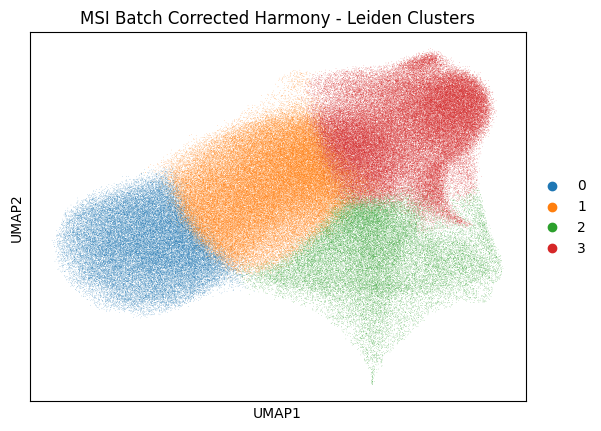

In [27]:
sc.pl.umap(msi_dataset, color=['leiden'], title="MSI Batch Corrected Harmony - Leiden Clusters", save="_msi_batch_corrected_harmony_leiden_clusters.png")

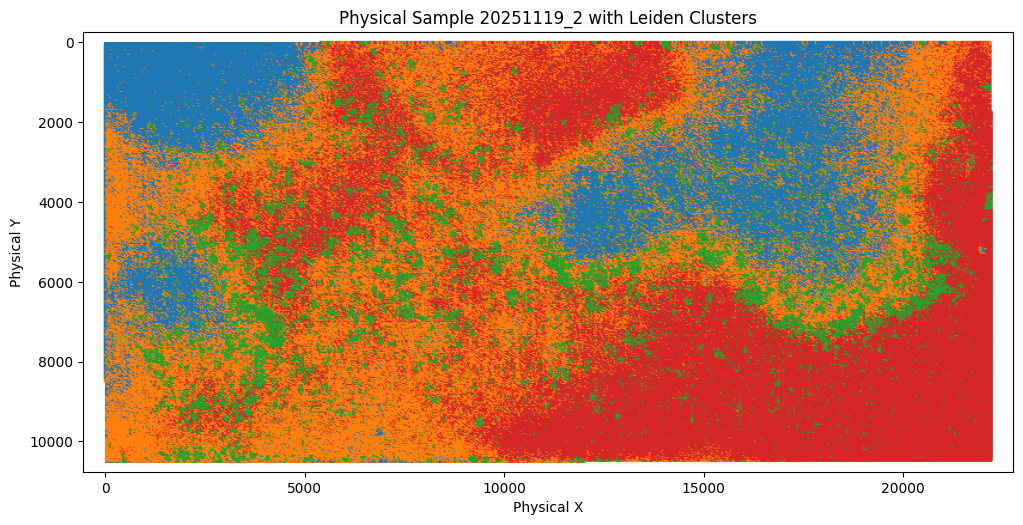

In [29]:
# Fetch the max coordinate in both axis to scale all the plots equally
max_x = msi_dataset.obsm['spatial'][:,0].max()
max_y = msi_dataset.obsm['spatial'][:,1].max()

for sample_id in msi_dataset.obs['sample_id'].unique():
    visualize_spot_spatial(
        clusters=msi_dataset[msi_dataset.obs['sample_id'] == sample_id].obs['leiden'].to_numpy(),
        physical_coords=msi_dataset[msi_dataset.obs['sample_id'] == sample_id].obsm['spatial'],
        cluster_colors=msi_dataset.uns['leiden_colors'],
        title=f"Physical Sample {sample_id} with Leiden Clusters",
        max_coords_value=(max_x, max_y)
    )